# Graph Convolutional Network (GCN)

## Learning Objectives

1. **Derive** the GCN layer propagation rule from spectral graph convolution
2. **Explain** the normalised adjacency $\tilde{A} = \tilde{D}^{-1/2}(A+I)\tilde{D}^{-1/2}$ and why self-loops are added
3. **Describe** the message-passing interpretation: aggregate, transform, activate
4. **Identify** the over-smoothing problem and why it limits GCN depth
5. **Implement** a 2-layer GCN with backpropagation for node classification


## Problem Statement

### From Spectral to Spatial

Graph convolution is defined spectrally as filtering in the Fourier domain of the graph:
$$g_\theta \star x = U g_\theta(\Lambda) U^\top x$$
where $L = U \Lambda U^\top$ is the eigendecomposition of the graph Laplacian. This is $O(n^3)$ — too slow for large graphs.

**Kipf & Welling (2017)** approximated this with a first-order polynomial ($K=1$), simplifying to the elegant layer-wise rule:
$$H^{(l+1)} = \sigma\!\left(\tilde{A} H^{(l)} W^{(l)}\right)$$
where $\tilde{A} = \tilde{D}^{-1/2}(A+I)\tilde{D}^{-1/2}$ and $\tilde{D}_{ii} = \sum_j (A+I)_{ij}$.

**Per-node interpretation (message passing):**
$$h_v^{(l+1)} = \sigma\!\left(W^{(l)} \sum_{u \in \mathcal{N}(v) \cup \{v\}} \frac{h_u^{(l)}}{\sqrt{\tilde{d}_v \tilde{d}_u}}\right)$$
The $\frac{1}{\sqrt{\tilde{d}_v \tilde{d}_u}}$ normalisation prevents high-degree nodes from dominating.


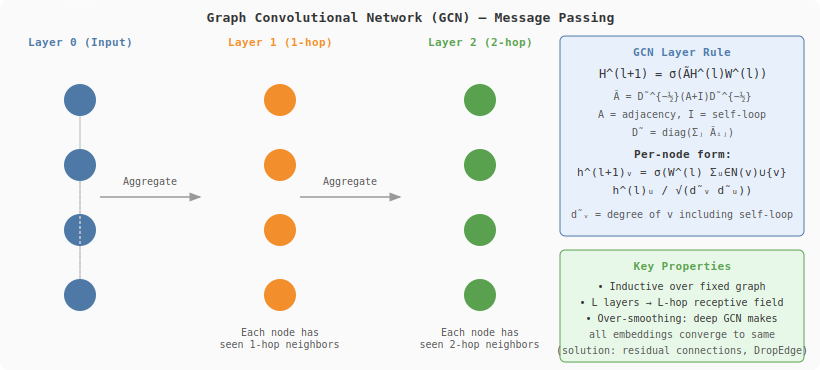

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="370" font-family="monospace" font-size="12">
  <rect width="820" height="370" fill="#fafafa" rx="8"/>
  <defs><marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#999"/></marker></defs>
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Graph Convolutional Network (GCN) — Message Passing</text>

  <!-- Layer 0: raw features -->
  <text x="80"  y="46" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">Layer 0 (Input)</text>
  <circle cx="80"  cy="100" r="16" fill="#4e79a7"/><text x="80"  cy="96"  text-anchor="middle" fill="white" font-size="9">A</text><text x="80" cy="108" text-anchor="middle" fill="white" font-size="7">[1,0]</text>
  <circle cx="80"  cy="165" r="16" fill="#4e79a7"/><text x="80"  cy="161" text-anchor="middle" fill="white" font-size="9">B</text><text x="80" cy="173" text-anchor="middle" fill="white" font-size="7">[0,1]</text>
  <circle cx="80"  cy="230" r="16" fill="#4e79a7"/><text x="80"  cy="226" text-anchor="middle" fill="white" font-size="9">C</text><text x="80" cy="238" text-anchor="middle" fill="white" font-size="7">[1,1]</text>
  <circle cx="80"  cy="295" r="16" fill="#4e79a7"/><text x="80"  cy="291" text-anchor="middle" fill="white" font-size="9">D</text><text x="80" cy="303" text-anchor="middle" fill="white" font-size="7">[0,0]</text>
  <!-- edges -->
  <line x1="80" y1="116" x2="80" y2="149" stroke="#ccc" stroke-width="1.5"/>
  <line x1="80" y1="181" x2="80" y2="214" stroke="#ccc" stroke-width="1.5"/>
  <line x1="80" y1="181" x2="80" y2="279" stroke="#ccc" stroke-width="1.5" stroke-dasharray="3,2"/>
  <line x1="80" y1="246" x2="80" y2="279" stroke="#ccc" stroke-width="1.5"/>

  <!-- Propagation arrow -->
  <line x1="100" y1="197" x2="200" y2="197" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>
  <text x="150" y="185" text-anchor="middle" fill="#555" font-size="10">Aggregate</text>

  <!-- Layer 1: after 1 hop -->
  <text x="280" y="46" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">Layer 1 (1-hop)</text>
  <circle cx="280" cy="100" r="16" fill="#f28e2b"/><text x="280" cy="96"  text-anchor="middle" fill="white" font-size="9">A'</text>
  <circle cx="280" cy="165" r="16" fill="#f28e2b"/><text x="280" cy="161" text-anchor="middle" fill="white" font-size="9">B'</text>
  <circle cx="280" cy="230" r="16" fill="#f28e2b"/><text x="280" cy="226" text-anchor="middle" fill="white" font-size="9">C'</text>
  <circle cx="280" cy="295" r="16" fill="#f28e2b"/><text x="280" cy="291" text-anchor="middle" fill="white" font-size="9">D'</text>
  <text x="280" y="336" text-anchor="middle" fill="#555" font-size="10">Each node has</text>
  <text x="280" y="348" text-anchor="middle" fill="#555" font-size="10">seen 1-hop neighbors</text>

  <line x1="300" y1="197" x2="400" y2="197" stroke="#999" stroke-width="1.5" marker-end="url(#arr)"/>
  <text x="350" y="185" text-anchor="middle" fill="#555" font-size="10">Aggregate</text>

  <!-- Layer 2: after 2 hops -->
  <text x="480" y="46" text-anchor="middle" fill="#59a14f" font-size="11" font-weight="bold">Layer 2 (2-hop)</text>
  <circle cx="480" cy="100" r="16" fill="#59a14f"/><text x="480" cy="96"  text-anchor="middle" fill="white" font-size="9">A''</text>
  <circle cx="480" cy="165" r="16" fill="#59a14f"/><text x="480" cy="161" text-anchor="middle" fill="white" font-size="9">B''</text>
  <circle cx="480" cy="230" r="16" fill="#59a14f"/><text x="480" cy="226" text-anchor="middle" fill="white" font-size="9">C''</text>
  <circle cx="480" cy="295" r="16" fill="#59a14f"/><text x="480" cy="291" text-anchor="middle" fill="white" font-size="9">D''</text>
  <text x="480" y="336" text-anchor="middle" fill="#555" font-size="10">Each node has</text>
  <text x="480" y="348" text-anchor="middle" fill="#555" font-size="10">seen 2-hop neighbors</text>

  <!-- Propagation rule -->
  <rect x="560" y="36" width="244" height="200" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="682" y="56" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">GCN Layer Rule</text>
  <text x="682" y="78" text-anchor="middle" fill="#333" font-size="12">H^(l+1) = σ(ÃH^(l)W^(l))</text>
  <text x="682" y="100" text-anchor="middle" fill="#555" font-size="10">Ã = D̃^{−½}(A+I)D̃^{−½}</text>
  <text x="682" y="118" text-anchor="middle" fill="#555" font-size="10">A = adjacency, I = self-loop</text>
  <text x="682" y="136" text-anchor="middle" fill="#555" font-size="10">D̃ = diag(Σⱼ Ãᵢⱼ)</text>
  <text x="682" y="158" text-anchor="middle" fill="#333" font-size="11" font-weight="bold">Per-node form:</text>
  <text x="682" y="176" text-anchor="middle" fill="#333" font-size="11">h^(l+1)ᵥ = σ(W^(l) Σᵤ∈N(v)∪{v}</text>
  <text x="682" y="194" text-anchor="middle" fill="#333" font-size="11">  h^(l)ᵤ / √(d̃ᵥ d̃ᵤ))</text>
  <text x="682" y="218" text-anchor="middle" fill="#555" font-size="10">d̃ᵥ = degree of v including self-loop</text>

  <!-- Properties -->
  <rect x="560" y="250" width="244" height="112" rx="5" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="682" y="270" text-anchor="middle" fill="#59a14f" font-size="11" font-weight="bold">Key Properties</text>
  <text x="682" y="290" text-anchor="middle" fill="#333" font-size="10">• Inductive over fixed graph</text>
  <text x="682" y="306" text-anchor="middle" fill="#333" font-size="10">• L layers → L-hop receptive field</text>
  <text x="682" y="322" text-anchor="middle" fill="#333" font-size="10">• Over-smoothing: deep GCN makes</text>
  <text x="682" y="338" text-anchor="middle" fill="#555" font-size="10">  all embeddings converge to same</text>
  <text x="682" y="354" text-anchor="middle" fill="#555" font-size="10">  (solution: residual connections, DropEdge)</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Why $A + I$?

Without self-loops, a node's own features are not included in the aggregation. Adding $I$ ensures every node aggregates itself — equivalent to saying the "message passing" includes the node's current representation.

### Why Symmetric Normalisation?

For node $v$ with degree $d_v$: without normalisation, the sum of neighbours' features grows with degree. The symmetric normalisation $\frac{1}{\sqrt{d_v d_u}}$ makes the scale invariant to degree, preventing feature explosion in dense regions.

### Semi-Supervised Node Classification

With only a few labelled nodes, GCN propagates label information through the graph:
1. Labelled nodes $\to$ training loss
2. Graph structure $\to$ smooth embedding across connected nodes
3. Unlabelled nodes can be classified at inference

**Objective:**
$$\mathcal{L} = -\sum_{v \in \mathcal{V}_L} \sum_{c} Y_{vc} \log P_{vc}$$
where $\mathcal{V}_L$ = labelled nodes, $P = \text{softmax}(\tilde{A} \cdot \text{relu}(\tilde{A} X W^{(1)}) \cdot W^{(2)})$.

### Over-Smoothing

After $L$ layers, each node's embedding averages information from its $L$-hop neighbourhood. For large $L$, all embeddings converge to the same vector (dominated by stationary distribution of the random walk on the graph). In practice, $L \leq 4$ layers is recommended.

**Solution:** Residual connections (GCNII), DropEdge (randomly drop edges during training), PairNorm.


## Algorithm Steps

1. **Precompute** $\tilde{A} = \tilde{D}^{-1/2}(A+I)\tilde{D}^{-1/2}$ (once, offline)
2. **Initialise** weight matrices $W^{(1)}, W^{(2)}$ randomly
3. **Forward pass:**
   - $H^{(1)} = \text{relu}(\tilde{A} X W^{(1)})$
   - $Z = \tilde{A} H^{(1)} W^{(2)}$
   - $P = \text{softmax}(Z)$
4. **Loss:** Cross-entropy on labelled nodes
5. **Backprop** via standard autodiff (here manual chain rule)
6. **Repeat** until convergence


In [2]:
import numpy as np


def gcn_layer(H, A_hat, W):
    """
    One GCN layer: H_new = relu(A_hat @ H @ W)
    A_hat : D^{-1/2}(A+I)D^{-1/2} — normalised adjacency with self-loops
    H     : (n, d_in) node feature matrix
    W     : (d_in, d_out) weight matrix
    """
    return np.maximum(0, A_hat @ H @ W)   # ReLU activation


def gcn_final_layer(H, A_hat, W):
    """Last layer without activation (for classification use softmax on output)."""
    return A_hat @ H @ W


def normalised_adjacency(A):
    """Compute Ã = D̃^{-½}(A+I)D̃^{-½}"""
    n = A.shape[0]
    A_tilde = A + np.eye(n)                     # add self-loops
    D_tilde = np.diag(A_tilde.sum(axis=1))
    d = np.diag(D_tilde)
    d_inv_sqrt = np.where(d > 0, d**(-0.5), 0)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    return D_inv_sqrt @ A_tilde @ D_inv_sqrt     # Ã


def softmax(X):
    e = np.exp(X - X.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)


def cross_entropy(Y_pred, Y_true):
    n = Y_true.shape[0]
    log_p = np.log(Y_pred + 1e-9)
    return -np.sum(Y_true * log_p) / n


class GCN:
    """
    2-layer GCN for semi-supervised node classification.

    Architecture: input → GCN(ReLU) → GCN → softmax → class probabilities
    """
    def __init__(self, d_in, d_hidden, d_out, seed=42):
        rng = np.random.default_rng(seed)
        scale = lambda a, b: np.sqrt(2.0 / (a + b))
        self.W1 = rng.normal(0, scale(d_in, d_hidden),     (d_in, d_hidden))
        self.W2 = rng.normal(0, scale(d_hidden, d_out),    (d_hidden, d_out))

    def forward(self, A_hat, X):
        self.H1 = gcn_layer(X, A_hat, self.W1)                  # shape (n, d_hidden)
        self.Z  = gcn_final_layer(self.H1, A_hat, self.W2)      # shape (n, d_out)
        self.P  = softmax(self.Z)
        return self.P

    def backward(self, A_hat, X, Y_true, train_mask, lr=0.01):
        n = X.shape[0]
        # Gradient of cross-entropy + softmax
        dZ = self.P.copy()
        dZ[train_mask] -= Y_true[train_mask]
        dZ /= train_mask.sum()

        # W2 gradient
        dW2 = self.H1.T @ (A_hat @ dZ)

        # Backprop through layer 1
        dH1 = (A_hat.T @ dZ) @ self.W2.T
        dH1[self.H1 <= 0] = 0             # ReLU gradient

        dW1 = X.T @ (A_hat @ dH1)

        self.W1 -= lr * dW1
        self.W2 -= lr * dW2

    def train(self, A_hat, X, Y, train_mask, n_epochs=200, lr=0.01):
        losses = []
        for epoch in range(n_epochs):
            P = self.forward(A_hat, X)
            loss = cross_entropy(P[train_mask], Y[train_mask])
            losses.append(loss)
            self.backward(A_hat, X, Y, train_mask, lr)
        return losses


# ── Demo: node classification on karate club-like graph ─────────────────────
rng = np.random.default_rng(0)

# Simple 2-community graph (12 nodes, 2 communities of 6)
n = 12
A = np.zeros((n, n))
for i in range(0, 6):
    for j in range(i+1, 6):
        A[i, j] = A[j, i] = 1
for i in range(6, 12):
    for j in range(i+1, 12):
        A[i, j] = A[j, i] = 1
A[5, 6] = A[6, 5] = 1    # bridge

# Node features: cluster membership signal + noise
X = rng.normal(0, 0.3, (n, 4))
X[:6, 0] += 1.0    # community 1 feature
X[6:, 1] += 1.0    # community 2 feature

# Labels: one-hot
Y = np.zeros((n, 2))
Y[:6, 0] = 1
Y[6:, 1] = 1

# Use 4 labelled nodes per class for training
train_mask = np.zeros(n, dtype=bool)
train_mask[[0, 1, 2, 3, 6, 7, 8, 9]] = True

A_hat = normalised_adjacency(A)
model = GCN(d_in=4, d_hidden=8, d_out=2)
losses = model.train(A_hat, X, Y, train_mask, n_epochs=300, lr=0.05)

P = model.forward(A_hat, X)
preds = np.argmax(P, axis=1)
true  = np.argmax(Y, axis=1)
acc   = np.mean(preds == true)

print(f"GCN node classification accuracy: {acc*100:.1f}%")
print(f"Training loss (start→mid→end): {losses[0]:.4f} → {losses[149]:.4f} → {losses[-1]:.4f}")
print(f"Predictions: {preds}")
print(f"True labels: {true}")


GCN node classification accuracy: 100.0%
Training loss (start→mid→end): 0.6534 → 0.1856 → 0.1633
Predictions: [0 0 0 0 0 0 1 1 1 1 1 1]
True labels: [0 0 0 0 0 0 1 1 1 1 1 1]
